In [1]:
# Fashion-MNIST CNN Classification

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

In [5]:
# Reshape to (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [6]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train for 20 epochs
history = model.fit(x_train, y_train, epochs=20, batch_size=64,
                    validation_split=0.2, verbose=2)

Epoch 1/20
750/750 - 10s - 13ms/step - accuracy: 0.8353 - loss: 0.4639 - val_accuracy: 0.8857 - val_loss: 0.3108
Epoch 2/20
750/750 - 3s - 5ms/step - accuracy: 0.8952 - loss: 0.2935 - val_accuracy: 0.9022 - val_loss: 0.2647
Epoch 3/20
750/750 - 5s - 7ms/step - accuracy: 0.9107 - loss: 0.2423 - val_accuracy: 0.9122 - val_loss: 0.2398
Epoch 4/20
750/750 - 4s - 5ms/step - accuracy: 0.9263 - loss: 0.2020 - val_accuracy: 0.9142 - val_loss: 0.2348
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.9372 - loss: 0.1707 - val_accuracy: 0.9151 - val_loss: 0.2470
Epoch 6/20
750/750 - 4s - 5ms/step - accuracy: 0.9471 - loss: 0.1445 - val_accuracy: 0.9143 - val_loss: 0.2718
Epoch 7/20
750/750 - 4s - 5ms/step - accuracy: 0.9550 - loss: 0.1211 - val_accuracy: 0.9188 - val_loss: 0.2601
Epoch 8/20
750/750 - 5s - 7ms/step - accuracy: 0.9622 - loss: 0.1021 - val_accuracy: 0.9183 - val_loss: 0.2877
Epoch 9/20
750/750 - 4s - 5ms/step - accuracy: 0.9677 - loss: 0.0862 - val_accuracy: 0.9179 - val_loss: 0.2915

In [10]:
# Plot accuracy & loss
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

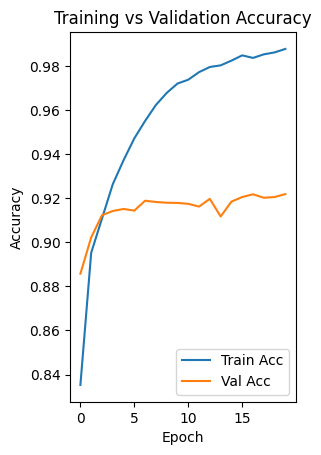

In [11]:
# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

#Overfittting

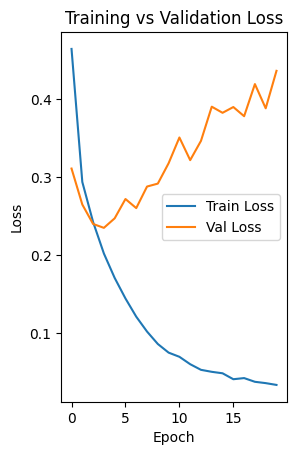

In [12]:
# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


#Overfitting

In [13]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Test Accuracy: 91.40%
